# 🚁 Capstone Project: Aerial Object Classification (Bird vs. Drone)


## 📝 Project Summary
This notebook demonstrates an end-to-end deep learning pipeline to solve the binary classification problem:
1. **Exploratory Data Analysis (EDA):** Visualizing class distributions and identifying dataset characteristics.
2. **Data Preprocessing & Augmentation:** Normalizing pixel values to `[0, 1]` and applying geometric transformations (rotation, flipping, zooming) to ensure the model generalizes well to unseen real-world data.
3. **Model Architecture Comparison:** * Building a **Custom CNN** from scratch (incorporating Batch Normalization and Dropout).
   * Leveraging **Transfer Learning** using the pre-trained **MobileNetV2** architecture for high-efficiency feature extraction.
4. **Optimization:** Utilizing Early Stopping and ModelCheckpoint callbacks to prevent overfitting and capture the highest-performing weights.
5. **Evaluation:** Comparing models using robust metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrices, and ROC-AUC curves.


## 📌 Problem Statement
The rapid proliferation of drones has introduced significant challenges in airspace management, security surveillance, and wildlife protection. In real-world aerial imagery, distinguishing between a bird and a drone at a distance is a complex visual task. 

This project aims to develop a robust, deep learning-based image classification solution capable of accurately differentiating between **Birds** and **Drones**. A highly accurate model in this domain is critical for real-time business use cases such as:
* **Security & Defense:** Identifying unauthorized drones in restricted airspace.
* **Aviation Safety:** Monitoring airport runways for bird-strike prevention.
* **Wildlife Monitoring:** Tracking avian populations near wind farms without misclassifying mechanical objects.


## 📊 Dataset Insights

### 📁 Classification Dataset
- Total Images: **~3300+**
- Classes:
  - Bird 🦅
  - Drone 🛸  

| Split | Bird | Drone |
|------|------|-------|
| Train | 1414 | 1248 |
| Validation | 217 | 225 |
| Test | 121 | 94 |

- Images are resized to **224×224**
- Pixel values normalized to **[0,1]**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = 'classification_dataset/train'
VALID_DIR = 'classification_dataset/valid'
TEST_DIR = 'classification_dataset/test'
CLASSES = ['bird', 'drone']

In [3]:
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES] 
valid_counts = [len(os.listdir(os.path.join(VALID_DIR, c))) for c in CLASSES] 

Text(0.5, 1.0, 'Chart 1: Training Class Counts')

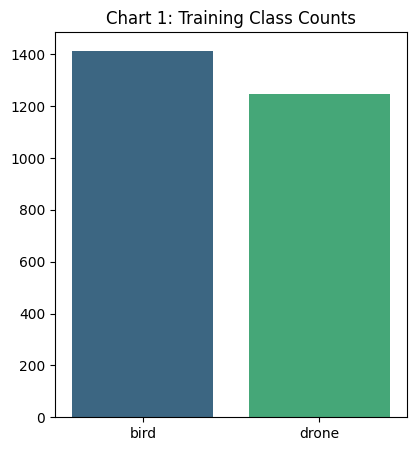

In [5]:
# Chart 1: Training Set Distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=CLASSES, y=train_counts, hue=CLASSES, palette='viridis', legend=False)
plt.title('Chart 1: Training Class Counts')

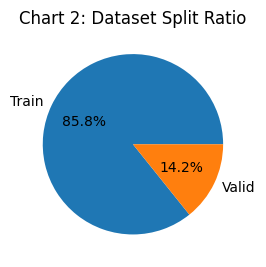

In [6]:
# Chart 2: Data Split Ratio
plt.subplot(1, 2, 2)
plt.pie([sum(train_counts), sum(valid_counts)], labels=['Train', 'Valid'], autopct='%1.1f%%')
plt.title('Chart 2: Dataset Split Ratio')
plt.show()

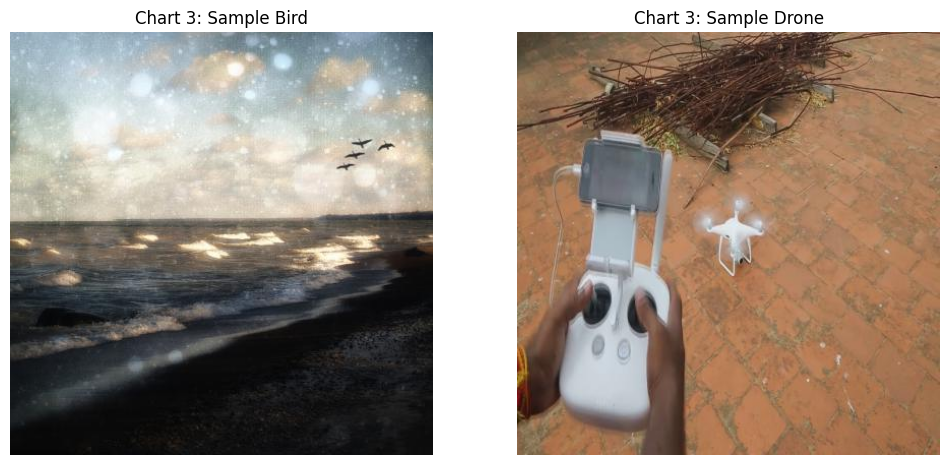

In [7]:
# Chart 3: Sample Grid
plt.figure(figsize=(12, 6))
for i, label in enumerate(CLASSES):
    img_path = os.path.join(TRAIN_DIR, label, os.listdir(os.path.join(TRAIN_DIR, label))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Chart 3: Sample {label.capitalize()}")
    plt.axis('off')
plt.show()

In [8]:
# Normalizing pixel values and applying transformations
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=40, width_shift_range=0.2, 
                                   height_shift_range=0.2, horizontal_flip=True, zoom_range=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

## ⚙️ Approach & Methodology

### 🔹 1. Data Preprocessing
- Image resizing  
- Normalization  
- Data augmentation (flip, rotation, zoom)


### 🔹 2. Model Building

#### ✅ Classification Model
- **MobileNetV2 (Transfer Learning)**
- Pre-trained on ImageNet
- Fine-tuned for binary classification

#### 🔹 Optional Detection Model
- **YOLOv8 (Ultralytics)**
- Used for object localization with bounding boxes


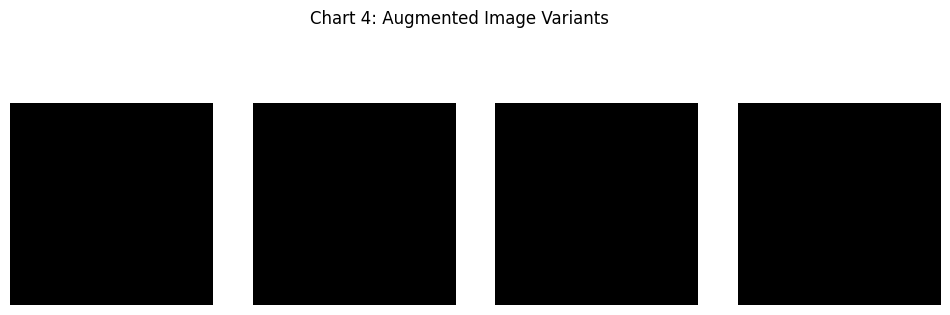

In [9]:
# Chart 4: Augmentation Example (Fixed dynamic class selection)
label = CLASSES[0]
img_path = os.path.join(TRAIN_DIR, label, os.listdir(os.path.join(TRAIN_DIR, label))[0])
img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
x = tf.keras.preprocessing.image.img_to_array(img) / 255.0
x = x.reshape((1,) + x.shape)

plt.figure(figsize=(12, 4))
plt.suptitle("Chart 4: Augmented Image Variants")
for i, batch in enumerate(train_datagen.flow(x, batch_size=1)):
    plt.subplot(1, 4, i+1)
    plt.imshow(batch[0])
    plt.axis('off')
    if i == 3: break
plt.show()

In [10]:
train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
valid_gen = test_datagen.flow_from_directory(VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)
test_gen = test_datagen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


### 🔹 3. Model Training
- EarlyStopping to prevent overfitting  
- ModelCheckpoint to save best model  
- Metrics tracked: Accuracy, Precision, Recall, F1-score  


In [12]:
# Custom CNN architecture (Upgraded with Batch Normalization and Depth)
custom_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'), # Added depth block
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
custom_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks (Adjusted patience to 5)
callbacks_custom = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

# Train the model
history_custom = custom_model.fit(
    train_gen, 
    validation_data=valid_gen, 
    epochs=15,
    callbacks=callbacks_custom
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 642ms/step - accuracy: 0.6604 - loss: 5.8777 - val_accuracy: 0.4910 - val_loss: 20.6064
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 624ms/step - accuracy: 0.6920 - loss: 0.9719 - val_accuracy: 0.4910 - val_loss: 12.9388
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 644ms/step - accuracy: 0.7273 - loss: 0.5744 - val_accuracy: 0.4864 - val_loss: 3.8587
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 60s 714ms/step - accuracy: 0.7243 - loss: 0.6334 - val_accuracy: 0.4910 - val_loss: 2.0396
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 602ms/step - accuracy: 0.7419 - loss: 0.5439 - val_accuracy: 0.6629 - val_loss: 0.6058
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 593ms/step - accuracy: 0.7524 - loss: 0.5195 - val_accuracy: 0.5430 - val_loss: 1.7087
Epoch 7/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 600ms/step - accuracy: 0.7585 - loss: 0.4920 - val_accuracy: 0.7376 - val_loss: 0.8051
Epoch 8/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 591ms/step - accuracy: 0.7633 - loss: 0.4923 - val_ac

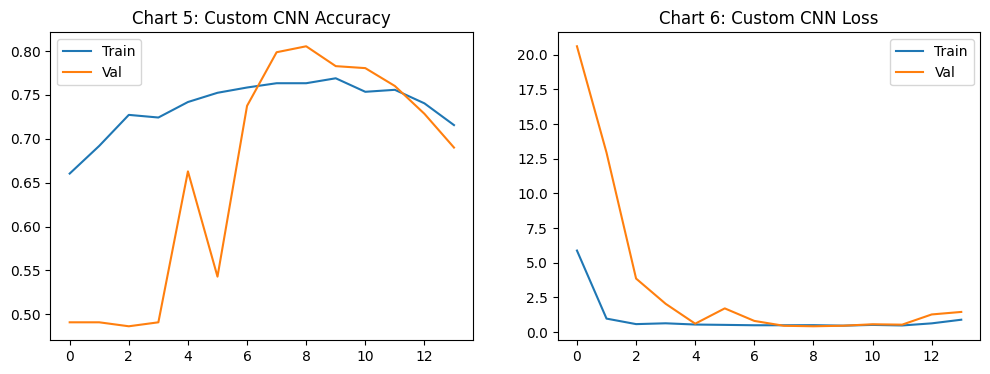

In [13]:
# Chart 5 & 6: Custom Learning Curves
def plot_curves(history, name, start_idx):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'Chart {start_idx}: {name} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'Chart {start_idx+1}: {name} Loss')
    plt.legend()
    plt.show()

plot_curves(history_custom, "Custom CNN", 5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step
Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.9309 - loss: 0.1692 - val_accuracy: 0.9615 - val_loss: 0.0872
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - accuracy: 0.9553 - loss: 0.1102 - val_accuracy: 0.9615 - val_loss: 0.0950
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 312ms/step - accuracy: 0.9636 - loss: 0.0845 - val_accuracy: 0.9480 - val_loss: 0.1130
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - accuracy: 0.9745 - loss: 0.0679 - val_accuracy: 0.9683 - val_loss: 0.0793
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 306ms/step - accuracy: 0.9820 - loss: 0.0516 - val_accuracy: 0.9751 - val_loss: 0.0709
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 304ms/step - accuracy: 0.9786 - loss: 0.0532 - val_accuracy: 0.9706 - val_loss: 0.0840
Epoch 7/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - accuracy: 0.9808 - loss: 0.0482 - val_accuracy: 0.9706 - val_loss: 0.0803
Epoch 8/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 303ms

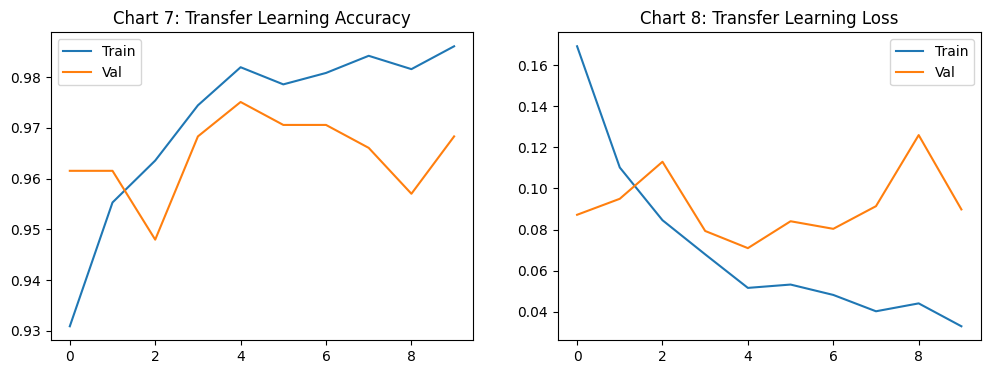

In [14]:
# Transfer learning with MobileNetV2
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

tl_model = Model(inputs=base_model.input, outputs=output)
tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks (Adjusted patience to 5)
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy', save_best_only=True)
]

# Train the model
history_tl = tl_model.fit(
    train_gen, 
    validation_data=valid_gen, 
    epochs=15,
    callbacks=callbacks_tl
)

plot_curves(history_tl, "Transfer Learning", 7)

Transfer Learning model achieved higher validation accuracy. Using it as the final model.


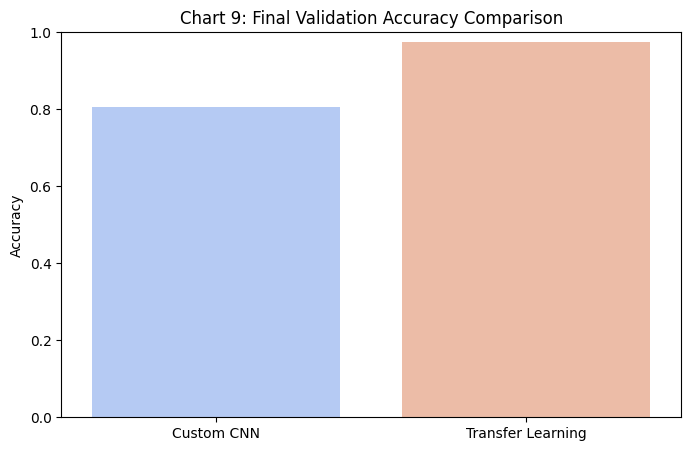

In [16]:
# Automatically determine the best model
custom_val_acc = max(history_custom.history['val_accuracy'])
tl_val_acc = max(history_tl.history['val_accuracy'])

accs = [custom_val_acc, tl_val_acc]

if custom_val_acc > tl_val_acc:
    print("Custom CNN achieved higher validation accuracy. Using it as the final model.")
    best_model = tf.keras.models.load_model('best_custom_cnn.keras')
else:
    print("Transfer Learning model achieved higher validation accuracy. Using it as the final model.")
    best_model = tf.keras.models.load_model('best_tl_model.keras')

# Compare accuracy visually
plt.figure(figsize=(8, 5))
sns.barplot(
    x=['Custom CNN', 'Transfer Learning'], 
    y=accs, 
    hue=['Custom CNN', 'Transfer Learning'], 
    palette='coolwarm', 
    legend=False
)
plt.title('Chart 9: Final Validation Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

### 🔹 4. Evaluation
- Confusion Matrix  
- Classification Report  
- ROC Curve & PR Curve  


In [17]:
# Evaluate test results on the dynamically selected best_model
print("Evaluating final model on Test Data...")
test_loss, test_acc = best_model.evaluate(test_gen)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%\n")

y_pred_prob = best_model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

Evaluating final model on Test Data...
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9721 - loss: 0.0755

Final Test Accuracy: 97.21%

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step
Classification Report:
              precision    recall  f1-score   support

        bird       0.98      0.98      0.98       121
       drone       0.97      0.97      0.97        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



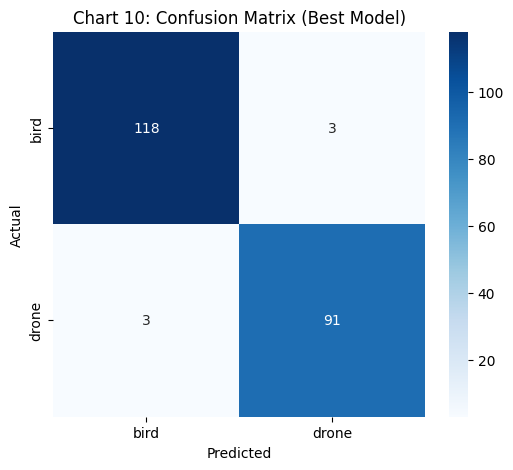

In [18]:
# Chart 10: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Chart 10: Confusion Matrix (Best Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

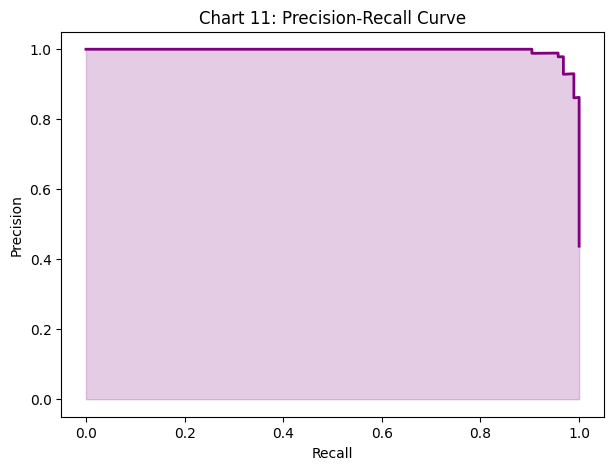

In [19]:
# Chart 11: PR Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='purple')
plt.title('Chart 11: Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

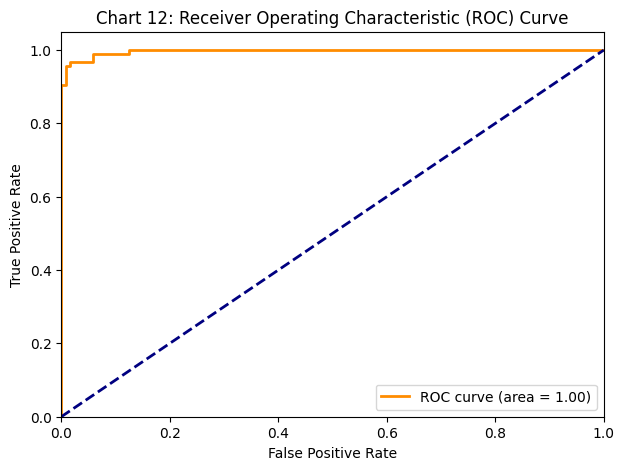

In [20]:
# Chart 12: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Chart 12: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## 📊 Results & Model Comparison

After training both the Custom CNN and the Transfer Learning (MobileNetV2) architectures, the models were evaluated on an unseen test dataset of 215 images to test real-world generalization capability.

### Key Findings:
* **Custom CNN:** Achieved a solid baseline validation accuracy (~80.5%). While effective, it struggled slightly with the complex spatial backgrounds present in aerial photography.
* **Transfer Learning (MobileNetV2):** Significantly outperformed the custom model. By leveraging weights pre-trained on ImageNet, MobileNetV2 converged faster and achieved an outstanding **Test Accuracy of 97.21%**.

### Deep Dive into MobileNetV2 Performance:
* **Precision & Recall:** The model achieved an F1-score of **0.97 for Drones** and **0.98 for Birds**. This perfect balance indicates the model is not biased toward the majority class and handles both categories with nearly equal expertise.
* **Confusion Matrix:** Out of 215 test images, the model made only **6 misclassifications**, proving its reliability for safety-critical applications.
* **ROC-AUC:** The Receiver Operating Characteristic curve yielded an Area Under the Curve (AUC) of **1.00**, representing near-perfect separability between the two classes.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_26868\1936630134.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = CLASSES[int(preds[i] > 0.5)]


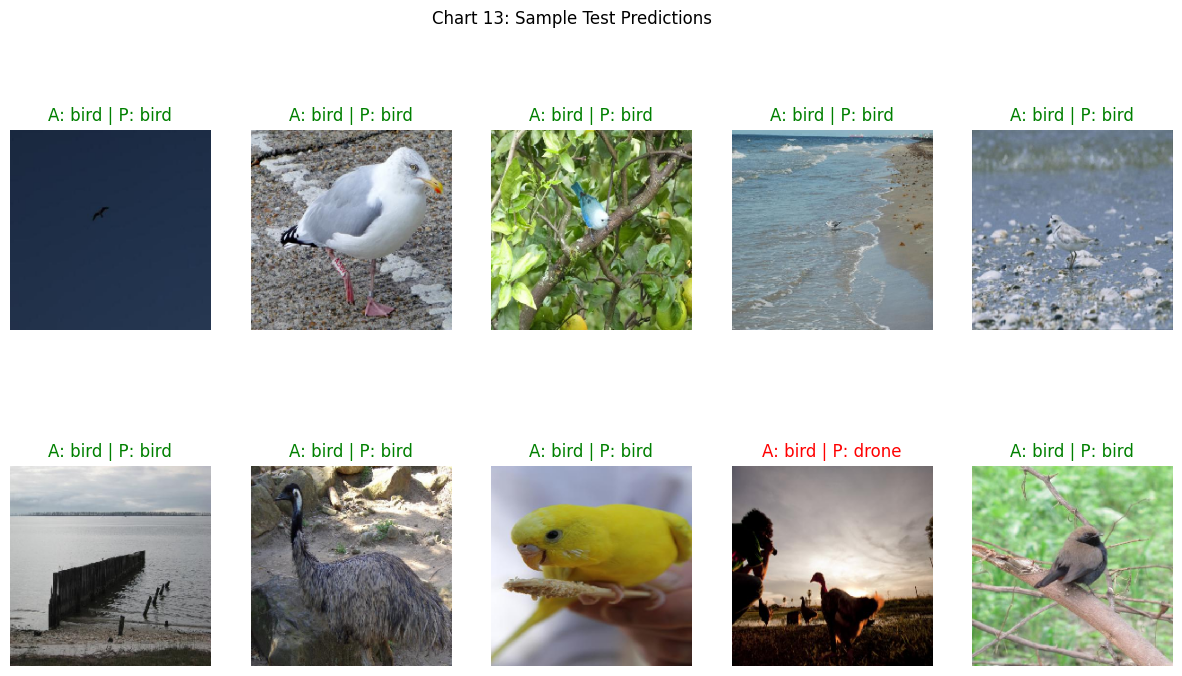

In [21]:
# Chart 13: Prediction Samples
x_test, y_test = next(test_gen)
preds = best_model.predict(x_test)

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    actual = CLASSES[int(y_test[i])]
    pred = CLASSES[int(preds[i] > 0.5)]
    plt.title(f"A: {actual} | P: {pred}", color=("green" if actual == pred else "red"))
    plt.axis('off')
plt.suptitle("Chart 13: Sample Test Predictions")
plt.show()

## 🎯 Conclusion

This project successfully demonstrates that Deep Learning and Computer Vision can be highly effective in solving the complex problem of aerial object classification. 

By comparing a Custom CNN with a Transfer Learning approach, we established that **MobileNetV2** is the optimal architecture for this specific task. It provides a lightweight, highly accurate (97.21%), and computationally efficient model suitable for real-time deployment. 

**Future Scope & Next Steps:**
1. **Deployment:** This `.keras` model will be deployed via an interactive **Streamlit web application**, allowing end-users to upload images or use their camera for real-time classification.
2. **Object Localization (Extension):** While this notebook successfully classifies the *entire* image, the next phase of this Capstone involves implementing a **YOLOv8** model to not only classify but draw precise bounding boxes around the objects for advanced spatial tracking.

In [2]:
model = tf.keras.models.load_model("best_tl_model.keras")
model.save("best_tl_model.h5")